In [1]:
from keras.layers import Input, Conv2D, BatchNormalization, ReLU, MaxPooling2D, Concatenate, GlobalMaxPooling2D, Dropout, Dense, Lambda, Reshape, Activation, Multiply, Add
from keras.applications import VGG16, DenseNet121, InceptionV3, VGG19, Xception, ResNet50
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from keras.layers import Input, Dropout, Dense, GlobalAveragePooling2D
from tool import load_data, draw_curve, draw_matrix, TimeHistory
from keras.models import Sequential, Model
from keras import backend as K
from tensorflow import keras
import tensorflow as tf
import numpy as np
import sys

2024-10-18 15:35:45.770375: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


100%|██████████| 1000/1000 [00:07<00:00, 129.40it/s]


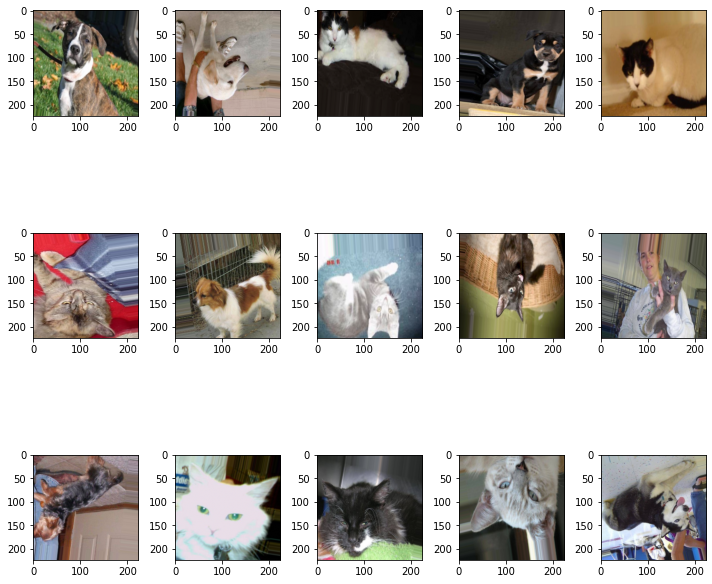

(2000, 224, 224, 3)
(7997, 224, 224, 3)
(2000, 2)
(7997, 2)


In [2]:
labels = ['cat', 'dog']
data_path = '/root/autodl-tmp/datasets/augmented'
image_size = 224
x_train, x_test, y_train, y_test = load_data(data_path, labels, image_size)

In [7]:
def block(inputs, filters):

    m = Conv2D(filters, 1, padding='same')(inputs)
    m = BatchNormalization()(m)
    m = ReLU()(m)

    a = Conv2D(filters, 3, padding='same')(inputs)
    a = BatchNormalization()(a)
    a = ReLU()(a)
    
    b = Concatenate()([m, a])

    d = Conv2D(filters * 2, 3, padding='same')(b)
    d = BatchNormalization()(d)
    d = ReLU()(d)

    d = Conv2D(filters * 2, 3, padding='same')(d)
    d = BatchNormalization()(d)
    d = ReLU()(d)
    
    x = Concatenate()([b, d])

    m = Conv2D(filters*4, 1, padding='same')(inputs)
    m = BatchNormalization()(m)
    m = ReLU()(m)
    
    x = Add()([m, x])

    y = Conv2D(filters*2, 1)(x)
    y = BatchNormalization()(y)
    y = ReLU()(y)
    
    return y

def load_model():
    
    K.clear_session()
    inputs = Input(shape=(image_size, image_size, 3))

    net = DenseNet121(weights='imagenet', include_top=False, input_tensor=inputs)

    for layer in net.layers:
        layer.trainable = False

    x = net.get_layer('pool4_conv').output
    x = block(x, 512)  

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(2, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=x)
    
    return model

In [8]:
model = load_model()
adam = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 230, 230, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                              

In [9]:
tensorboard = TensorBoard(log_dir = 'logs')
checkpoint = ModelCheckpoint(filepath='model-dogcat.h5',
                             monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.3, patience = 5, min_delta = 0.001,
                              mode='auto',verbose=1)
time_callback = TimeHistory()
history = model.fit(x_train,y_train,validation_split=0.1, epochs =25, verbose=1, batch_size=36,
                   callbacks=[tensorboard,checkpoint,reduce_lr, time_callback])

Epoch 1/25
161/200 [=======================>......] - ETA: 1s - loss: 0.1642 - accuracy: 0.9332

200/200 [==============================] - ETA: 0s - loss: 0.1547 - accuracy: 0.9376
Epoch 1: val_accuracy improved from -inf to 0.88750, saving model to model-dogcat.h5
Epoch 1: 17.54 seconds
200/200 [==============================] - 18s 64ms/step - loss: 0.1547 - accuracy: 0.9376 - val_loss: 0.3699 - val_accuracy: 0.8875 - lr: 1.0000e-04
Epoch 2/25
199/200 [============================>.] - ETA: 0s - loss: 0.0774 - accuracy: 0.9707
Epoch 2: val_accuracy improved from 0.88750 to 0.98250, saving model to model-dogcat.h5
Epoch 2: 9.67 seconds
200/200 [==============================] - 10s 48ms/step - loss: 0.0771 - accuracy: 0.9708 - val_loss: 0.0932 - val_accuracy: 0.9825 - lr: 1.0000e-04
Epoch 3/25
199/200 [============================>.] - ETA: 0s - loss: 0.0498 - accuracy: 0.9834
Epoch 3: val_accuracy did not improve from 0.98250
Epoch 3: 8.93 seconds
200/200 [==============================] - 9s 45ms/step - loss: 0.0497 - accuracy: 0.9833 - val_loss: 0.2358 - val_accuracy: 0.9175 

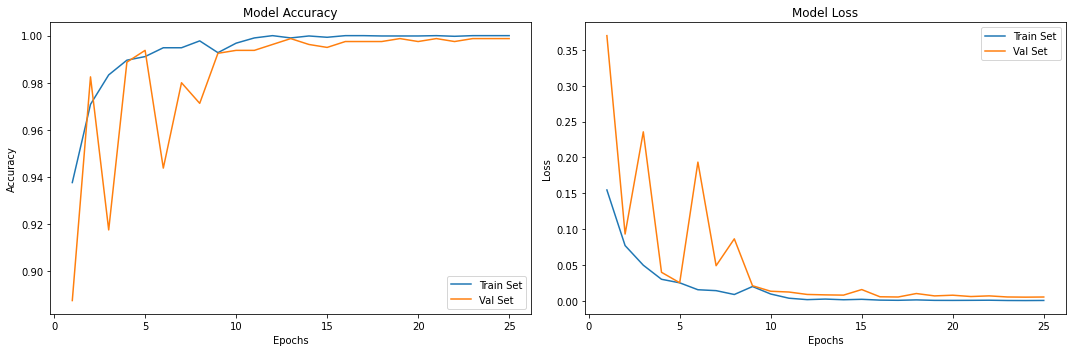

63/63 [==============================] - 2s 26ms/step - loss: 0.0646 - accuracy: 0.9845
Test Accuracy:  98.45
              precision    recall  f1-score   support

         cat     0.9869    0.9820    0.9845      1000
         dog     0.9821    0.9870    0.9845      1000

    accuracy                         0.9845      2000
   macro avg     0.9845    0.9845    0.9845      2000
weighted avg     0.9845    0.9845    0.9845      2000



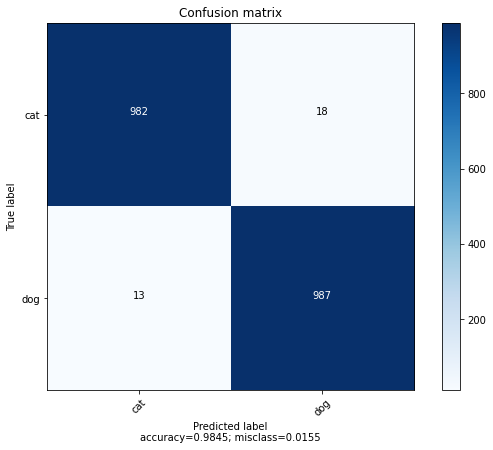

In [10]:
draw_curve(history)
pred = model.predict(x_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)
loss,acc = model.evaluate(x_test,y_test,verbose = 1)
draw_matrix(labels, y_test_new, pred, acc)

In [12]:
from keras.models import load_model
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import cv2


model = load_model('/root/autodl-tmp/model-dogcat.h5')
test_image_folder = '/root/autodl-tmp/datasets/test'
results = []

for img_name in os.listdir(test_image_folder):
    image = cv2.imread(os.path.join(test_image_folder, img_name)) 
    image = cv2.bilateralFilter(image, 2, 50, 50)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    image = np.array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    prediction = model.predict(image)
    class_index = np.argmax(prediction)
    results.append([os.path.splitext(img_name)[0], class_index])


df_results = pd.DataFrame(results, columns=['id', 'label'])
output_file = 'sampleSubmission.csv'
df_results.to_csv(output_file, index=False)


1/1 [==============================] - 0s 31ms/step


1/1 [==============================] - 0s 35ms/step
